# Notebook 02 — SVI / SSVI Benchmark (real SPX data)

**The bar the deep-learning models must beat.** Before any neural smoother, we calibrate the parametric models of Gatheral & Jacquier properly. Without a credible benchmark, no "neural" result means anything.

This notebook:
1. Implements the **quasi-explicit SVI calibration** (De Marco–Martini / Zeliade) — the robust way to fit SVI without local minima.
2. Checks **butterfly no-arbitrage** on every slice via the Durrleman function $g(k)$.
3. Calibrates **SSVI** on each day's surface, with the Gatheral–Jacquier butterfly and calendar conditions.
4. **Self-validates on a synthetic surface** with known parameters (which it must recover).
5. Runs the **real-data driver** on `option_prices_clean.parquet` from NB01: one slice per **`exdate`**, SVI per slice and SSVI per day, arbitrage diagnostics, and aggregated metrics saved to Parquet.

**Key point on slicing.** A *slice* is one exact expiration. We group by **`exdate`**, never by a rounded `tau` — this is what prevents mixing a standard SPX expiry with a same-day SPXW into one polluted smile.

**Quasi-explicit idea.** Raw SVI: $w(k)=a+b\big(\rho(k-m)+\sqrt{(k-m)^2+\sigma^2}\big)$. Freezing $(m,\sigma)$ and setting $y=(k-m)/\sigma$ gives $w=a+d\,y+c\sqrt{y^2+1}$ with $c=b\sigma,\ d=\rho b\sigma$ — **linear** in $(a,d,c)$. The inner problem is a **convex** least squares under linear no-arbitrage constraints; only $(m,\sigma)$ are optimized in 2-D.


In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.2); plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = .3

# --- config ---
REAL_PARQUET  = Path(os.environ.get("THESIS_OPT_PARQUET", "data/clean/option_prices_clean.parquet"))
OUT_DIR       = Path(os.environ.get("THESIS_OUT_DIR", "data/clean")); OUT_DIR.mkdir(parents=True, exist_ok=True)
MIN_PTS_SLICE = 6          # minimum quotes per expiration to calibrate a 5-parameter SVI
MIN_SLICES    = 2          # minimum slices per day to attempt an SSVI fit
LIMIT_DATES   = 8          # None = all trading days; an int = subsample (for a quick first pass)
WEIGHT_MODE   = "uniform"  # "uniform" or "inv_spread"


## 1. SVI building blocks and the butterfly diagnostic

Raw SVI and its closed-form derivatives, plus the Durrleman function $g(k)$. Recall: $g(k)\ge 0$ everywhere ⟺ non-negative risk-neutral density ⟺ no butterfly arbitrage.

In [2]:
def svi_raw(k, a, b, rho, m, sigma):
    k = np.asarray(k, float); return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))
def svi_prime(k, a, b, rho, m, sigma):
    k = np.asarray(k, float); return b * (rho + (k - m) / np.sqrt((k - m) ** 2 + sigma ** 2))
def svi_double(k, a, b, rho, m, sigma):
    k = np.asarray(k, float); return b * sigma ** 2 / ((k - m) ** 2 + sigma ** 2) ** 1.5
def durrleman_g(k, w, wp, wpp):
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2

def svi_min_g(params, k_lo, k_hi, n=400):
    """Minimum of g(k) over [k_lo, k_hi]; < 0 means butterfly arbitrage."""
    k = np.linspace(k_lo, k_hi, n)
    return float(np.min(durrleman_g(k, svi_raw(k, **params),
                                    svi_prime(k, **params), svi_double(k, **params))))


## 2. Quasi-explicit SVI calibration

`_svi_inner` solves the **convex** inner problem for fixed $(m,\sigma)$ (variables $a,d,c$, no-arbitrage wing constraints). `fit_svi_slice` runs the 2-D outer optimization over $(m,\sigma)$ (Nelder–Mead, a few restarts) and reconstructs $(a,b,\rho,m,\sigma)$.

In [3]:
def _svi_inner(m, s, k, w, wt):
    y = (k - m) / s
    z = np.sqrt(y * y + 1.0)
    A = np.column_stack([np.ones_like(y), y, z])
    def obj(x):
        r = A @ x - w; return float(np.sum(wt * r * r))
    def grad(x):
        r = A @ x - w; return 2.0 * A.T @ (wt * r)
    wmax = float(max(w.max(), 1e-6))
    cons = [
        {"type": "ineq", "fun": lambda x: x[2]},                  # c >= 0
        {"type": "ineq", "fun": lambda x: 4 * s - x[2]},          # c <= 4s
        {"type": "ineq", "fun": lambda x: x[2] - x[1]},           # d <= c
        {"type": "ineq", "fun": lambda x: x[2] + x[1]},           # d >= -c
        {"type": "ineq", "fun": lambda x: (4 * s - x[2]) - x[1]}, # d <= 4s - c
        {"type": "ineq", "fun": lambda x: x[1] - (x[2] - 4 * s)}, # d >= c - 4s
        {"type": "ineq", "fun": lambda x: x[0]},                  # a >= 0
        {"type": "ineq", "fun": lambda x: wmax - x[0]},           # a <= max w
    ]
    x0 = np.array([np.median(w), 0.0, min(2 * s, wmax)])
    res = minimize(obj, x0, jac=grad, method="SLSQP", constraints=cons,
                   options={"maxiter": 200, "ftol": 1e-14})
    return res.x, res.fun


def fit_svi_slice(k, w, weights=None, restarts=((0.0, 0.1), (0.0, 0.2), (-0.05, 0.3))):
    """Calibrate raw SVI on one slice (k, w = total variance). Returns (params, rmse_w)."""
    k = np.asarray(k, float); w = np.asarray(w, float)
    wt = np.ones_like(w) if weights is None else np.asarray(weights, float)
    best = None
    for (m0, s0) in restarts:
        def outer(ms):
            m, ls = ms; _, f = _svi_inner(m, np.exp(ls), k, w, wt); return f
        r = minimize(outer, [m0, np.log(s0)], method="Nelder-Mead",
                     options={"xatol": 1e-6, "fatol": 1e-14, "maxiter": 400})
        m, ls = r.x; s = float(np.exp(ls))
        x, f = _svi_inner(m, s, k, w, wt)
        if best is None or f < best[0]:
            a, d, c = x; b = c / s
            rho = float(np.clip(d / c, -0.9999, 0.9999)) if c > 1e-12 else 0.0
            best = (f, dict(a=float(a), b=float(b), rho=rho, m=float(m), sigma=s))
    _, p = best
    rmse = float(np.sqrt(np.mean((svi_raw(k, **p) - w) ** 2)))
    return p, rmse


## 3. Synthetic validation of the SVI calibrator

We generate a slice from a **known** SSVI, sample it sparsely with noise, calibrate SVI, and check that the fit is accurate and butterfly-free.

SVI params: {'a': 0.0124, 'b': 0.0291, 'rho': -0.8183, 'm': 0.1029, 'sigma': 0.1514}
RMSE (total variance) = 9.95e-05
min g(k) = 0.4590  -> OK (arbitrage-free)


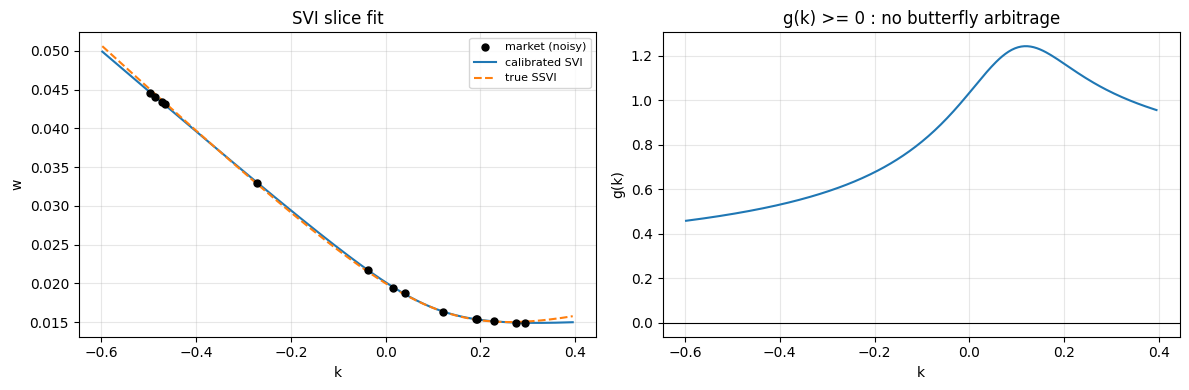

In [4]:
def ssvi_w(k, theta, rho, eta, gamma):
    k = np.asarray(k, float); phi = eta * theta ** (-gamma)
    return 0.5 * theta * (1 + rho * phi * k + np.sqrt((phi * k + rho) ** 2 + (1 - rho ** 2)))

TRUE = dict(rho=-0.5, eta=0.8, gamma=0.4)
rng = np.random.default_rng(0)

theta0 = 0.04 * 0.5
k_obs = np.sort(rng.uniform(-0.5, 0.35, 14))
w_obs = ssvi_w(k_obs, theta0, **TRUE) * (1 + 0.01 * rng.standard_normal(len(k_obs)))
params, rmse = fit_svi_slice(k_obs, w_obs)
ming = svi_min_g(params, k_obs.min() - 0.1, k_obs.max() + 0.1)
print("SVI params:", {k: round(v, 4) for k, v in params.items()})
print(f"RMSE (total variance) = {rmse:.2e}")
print(f"min g(k) = {ming:.4f}  -> {'OK (arbitrage-free)' if ming >= 0 else 'ARBITRAGE'}")

kk = np.linspace(k_obs.min() - 0.1, k_obs.max() + 0.1, 300)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(k_obs, w_obs, s=25, c="k", zorder=3, label="market (noisy)")
ax[0].plot(kk, svi_raw(kk, **params), label="calibrated SVI")
ax[0].plot(kk, ssvi_w(kk, theta0, **TRUE), "--", label="true SSVI")
ax[0].set(title="SVI slice fit", xlabel="k", ylabel="w"); ax[0].legend(fontsize=8)
g = durrleman_g(kk, svi_raw(kk, **params), svi_prime(kk, **params), svi_double(kk, **params))
ax[1].axhline(0, color="k", lw=.8); ax[1].plot(kk, g)
ax[1].set(title="g(k) >= 0 : no butterfly arbitrage", xlabel="k", ylabel="g(k)")
plt.tight_layout(); plt.show()


## 4. SSVI (whole-surface) calibration with no-arbitrage conditions

SSVI ties the slices together: $w(k,\theta)=\tfrac{\theta}{2}\big(1+\rho\varphi(\theta)k+\sqrt{(\varphi(\theta)k+\rho)^2+1-\rho^2}\big)$ with $\varphi(\theta)=\eta\theta^{-\gamma}$ and $\theta$ the ATM total variance of each maturity (since $w(0,\theta)=\theta$).

**No-arbitrage conditions (Gatheral–Jacquier):**
- *Butterfly:* $\theta\varphi(\theta)(1+|\rho|)\le 4$ **and** $\theta\varphi(\theta)^2(1+|\rho|)\le 4$ over the observed $\theta$ range.
- *Calendar:* $\theta$ increasing in maturity (slices of $w$ do not cross).

We estimate $\theta$ from each slice's ATM total variance (via the fitted SVI), then fit $(\rho,\eta,\gamma)$ globally under those constraints.

In [5]:
def fit_ssvi(thetas, k_list, w_list):
    TH = np.asarray(thetas, float)
    K = [np.asarray(x, float) for x in k_list]
    Wm = [np.asarray(x, float) for x in w_list]
    def sse(p):
        rho, eta, gamma = p; tot = 0.0
        for th, kk, wm in zip(TH, K, Wm):
            tot += np.sum((ssvi_w(kk, th, rho, eta, gamma) - wm) ** 2)
        return tot
    def phi(th, eta, gamma): return eta * th ** (-gamma)
    cons = [
        {"type": "ineq", "fun": lambda p: 0.999 - abs(p[0])},
        {"type": "ineq", "fun": lambda p: p[1] - 1e-6},
        {"type": "ineq", "fun": lambda p: p[2] - 1e-6},
        {"type": "ineq", "fun": lambda p: 0.5 - p[2]},
        {"type": "ineq", "fun": lambda p: 4 - np.max(TH * phi(TH, p[1], p[2]) * (1 + abs(p[0])))},
        {"type": "ineq", "fun": lambda p: 4 - np.max(TH * phi(TH, p[1], p[2]) ** 2 * (1 + abs(p[0])))},
    ]
    best = None
    for init in [(-0.5, 1.0, 0.3), (-0.7, 0.5, 0.4), (-0.3, 1.5, 0.25)]:
        r = minimize(sse, init, method="SLSQP", constraints=cons,
                     options={"maxiter": 300, "ftol": 1e-14})
        if best is None or r.fun < best.fun: best = r
    rho, eta, gamma = best.x
    npts = sum(len(x) for x in K)
    return dict(rho=float(rho), eta=float(eta), gamma=float(gamma)), float(np.sqrt(best.fun / max(npts, 1)))


def ssvi_calendar_ok(thetas, params, k_lo=-0.5, k_hi=0.5, n=200):
    TH = np.sort(np.asarray(thetas, float)); kk = np.linspace(k_lo, k_hi, n)
    W = np.vstack([ssvi_w(kk, th, **params) for th in TH])
    return bool(np.all(np.diff(W, axis=0) >= -1e-10))


In [6]:
# --- synthetic validation of the SSVI calibrator ---
taus = np.array([0.1, 0.25, 0.5, 1.0, 1.5, 2.0])
thetas_true = 0.04 * taus
k_list, w_list, thetas_svi = [], [], []
for th in thetas_true:
    kk = np.sort(rng.uniform(-0.6, 0.4, 16))
    wm = ssvi_w(kk, th, **TRUE) * (1 + 0.01 * rng.standard_normal(len(kk)))
    k_list.append(kk); w_list.append(wm)
    p_slice, _ = fit_svi_slice(kk, wm)
    thetas_svi.append(svi_raw(0.0, **p_slice))

ssvi_params, ssvi_rmse = fit_ssvi(thetas_svi, k_list, w_list)
cal_ok = ssvi_calendar_ok(thetas_svi, ssvi_params)
print("true SSVI     :", TRUE)
print("fitted SSVI   :", {k: round(v, 4) for k, v in ssvi_params.items()})
print(f"RMSE = {ssvi_rmse:.2e}   |   calendar: {'OK' if cal_ok else 'VIOLATION'}")


true SSVI     : {'rho': -0.5, 'eta': 0.8, 'gamma': 0.4}
fitted SSVI   : {'rho': -0.4961, 'eta': 0.7895, 'gamma': 0.4085}
RMSE = 6.50e-04   |   calendar: OK


The recovered $(\rho,\eta,\gamma)$ should be close to the true values with a tiny RMSE and calendar arbitrage satisfied — this validates the calibration machinery before applying it to real data.

## 5. Real-data driver (SPX)

We load `option_prices_clean.parquet` (NB01), keep OTM quotes, and for each trading day build **one slice per `exdate`**. Market total variance is $w=\sigma_{\text{IV}}^2\,\tau$ from `iv_om`. We calibrate SVI per slice and SSVI per day, and record the fit error (in vol points) and arbitrage violations.

> This is heavy (one optimization per slice). Use `LIMIT_DATES` to test on a few days first; set it to `None` to process everything.

In [7]:
import polars as pl

def slices_for_date(df_day):
    """One slice per exdate: returns [(tau, k[], w[], weight[]), ...] sorted by tau."""
    out = []
    for key, sub in df_day.group_by("exdate"):
        sub = sub.sort("k")
        k = sub["k"].to_numpy()
        iv = sub["iv_om"].to_numpy()
        tau = float(sub["tau"][0])
        ok = np.isfinite(k) & np.isfinite(iv) & (iv > 0)
        k, iv = k[ok], iv[ok]
        if len(k) < MIN_PTS_SLICE:
            continue
        if WEIGHT_MODE == "inv_spread" and "spread" in sub.columns:
            sp = sub["spread"].to_numpy()[ok]
            wt = 1.0 / np.maximum(sp, 1e-6); wt = wt / wt.mean()
        else:
            wt = np.ones_like(k)
        out.append((tau, k, iv ** 2 * tau, wt))
    return sorted(out, key=lambda t: t[0])


def calibrate_day(df_day):
    slices = slices_for_date(df_day)
    if len(slices) < MIN_SLICES:
        return None
    rows, k_list, w_list, thetas = [], [], [], []
    for tau, k, w, wt in slices:
        p, _ = fit_svi_slice(k, w, weights=wt)
        ming = svi_min_g(p, k.min() - 0.05, k.max() + 0.05)
        iv_fit = np.sqrt(np.maximum(svi_raw(k, **p), 1e-12) / tau)
        iv_mkt = np.sqrt(w / tau)
        rmse_iv = float(np.sqrt(np.mean((iv_fit - iv_mkt) ** 2)))
        rows.append(dict(tau=tau, n=len(k), svi_rmse_iv=rmse_iv, svi_min_g=ming, **p))
        k_list.append(k); w_list.append(w); thetas.append(svi_raw(0.0, **p))
    ssvi_p, _ = fit_ssvi(thetas, k_list, w_list)
    cal_ok = ssvi_calendar_ok(thetas, ssvi_p)
    ssvi_rmse_iv = float(np.sqrt(np.mean([
        np.mean((np.sqrt(np.maximum(ssvi_w(k, th, **ssvi_p), 1e-12) / tau) - np.sqrt(w / tau)) ** 2)
        for (tau, k, w, _), th in zip(slices, thetas)
    ])))
    return dict(rows=rows, ssvi=ssvi_p, ssvi_rmse_iv=ssvi_rmse_iv,
                calendar_ok=cal_ok, n_slices=len(slices))


In [8]:
if not REAL_PARQUET.exists():
    print(f"[info] {REAL_PARQUET} not found - real-data section skipped.")
    print("       Run NB01 to produce the dataset, then re-run this section.")
    results = None
else:
    need = ["date", "exdate", "tau", "k", "iv_om", "is_otm"]
    df = (pl.scan_parquet(REAL_PARQUET)
            .filter(pl.col("is_otm"))
            .select(need + (["spread"] if WEIGHT_MODE == "inv_spread" else []))
            .drop_nulls(["date", "exdate", "tau", "k", "iv_om"])
            .collect(engine="streaming"))
    dates = df["date"].unique().sort().to_list()
    if LIMIT_DATES:
        dates = dates[:LIMIT_DATES]
    print(f"calibrating {len(dates)} day(s)...")

    per_slice, per_day = [], []
    for d in dates:
        res = calibrate_day(df.filter(pl.col("date") == d))
        if res is None:
            continue
        for r in res["rows"]:
            per_slice.append({"date": d, **r})
        per_day.append({"date": d, "n_slices": res["n_slices"],
                        "ssvi_rmse_iv": res["ssvi_rmse_iv"], "calendar_ok": res["calendar_ok"],
                        **{f"ssvi_{k}": v for k, v in res["ssvi"].items()}})
    results = (pl.DataFrame(per_slice), pl.DataFrame(per_day))
    print("done:", results[0].height, "slices,", results[1].height, "days")


calibrating 8 day(s)...
done: 258 slices, 8 days


### 5b. Aggregation and comparison

SVI  : median IV RMSE = 0.790 vol pts  (90th pct = 1.098)
SSVI : median IV RMSE = 2.296 vol pts
SVI slices with butterfly arbitrage (min g < 0): 8.91%
Days with calendar-arbitrage-free SSVI: 100.0%


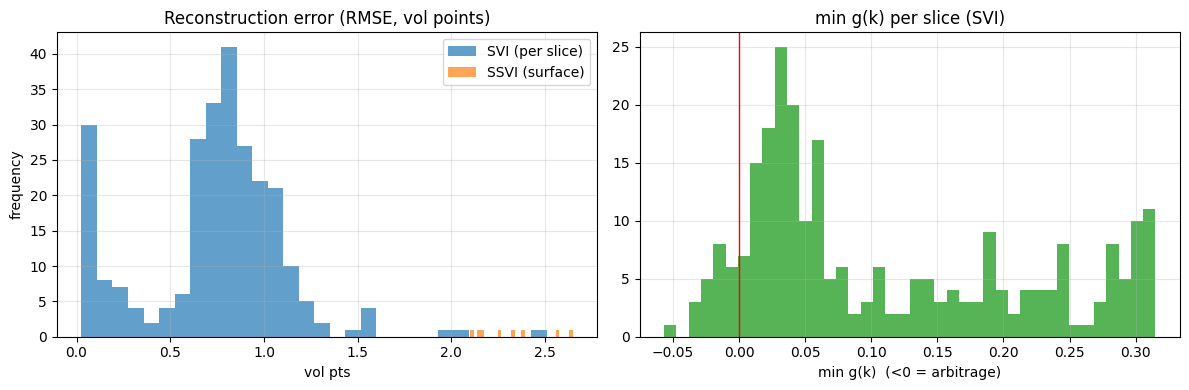

In [9]:
if results is not None and results[0].height:
    slice_df, day_df = results
    svi_iv = slice_df["svi_rmse_iv"].to_numpy() * 100      # vol points (%)
    ssvi_iv = day_df["ssvi_rmse_iv"].to_numpy() * 100
    viol = (slice_df["svi_min_g"].to_numpy() < -1e-6).mean() * 100

    print(f"SVI  : median IV RMSE = {np.median(svi_iv):.3f} vol pts  "
          f"(90th pct = {np.quantile(svi_iv, 0.9):.3f})")
    print(f"SSVI : median IV RMSE = {np.median(ssvi_iv):.3f} vol pts")
    print(f"SVI slices with butterfly arbitrage (min g < 0): {viol:.2f}%")
    print(f"Days with calendar-arbitrage-free SSVI: {day_df['calendar_ok'].mean()*100:.1f}%")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(svi_iv, bins=30, alpha=0.7, label="SVI (per slice)")
    ax[0].hist(ssvi_iv, bins=30, alpha=0.7, label="SSVI (surface)")
    ax[0].set(title="Reconstruction error (RMSE, vol points)",
              xlabel="vol pts", ylabel="frequency"); ax[0].legend()
    ax[1].hist(slice_df["svi_min_g"].to_numpy(), bins=40, color="tab:green", alpha=0.8)
    ax[1].axvline(0, color="r", lw=1)
    ax[1].set(title="min g(k) per slice (SVI)", xlabel="min g(k)  (<0 = arbitrage)")
    plt.tight_layout(); plt.show()
else:
    print("Aggregation skipped (no real data).")


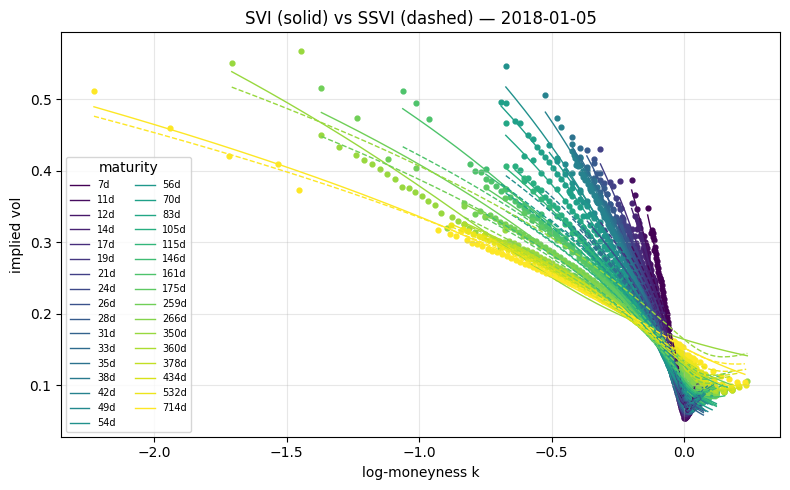

In [10]:
# --- example day: market points + SVI and SSVI fits ---
if results is not None and results[1].height:
    slice_df, day_df = results
    d0 = day_df.sort("n_slices", descending=True)["date"][0]
    day = df.filter((pl.col("date") == d0) & pl.col("is_otm"))
    slices = slices_for_date(day)
    thetas = []
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(slices)))
    svi_params = []
    for (tau, k, w, wt), c in zip(slices, cmap):
        p, _ = fit_svi_slice(k, w, weights=wt); svi_params.append(p); thetas.append(svi_raw(0.0, **p))
        kk = np.linspace(k.min(), k.max(), 200)
        ax.scatter(k, np.sqrt(w / tau), s=12, color=c)
        ax.plot(kk, np.sqrt(np.maximum(svi_raw(kk, **p), 1e-12) / tau), color=c, lw=1,
                label=f"{tau*365:.0f}d")
    ssvi_p, _ = fit_ssvi(thetas, [s[1] for s in slices], [s[2] for s in slices])
    for (tau, k, w, wt), th, c in zip(slices, thetas, cmap):
        kk = np.linspace(k.min(), k.max(), 200)
        ax.plot(kk, np.sqrt(np.maximum(ssvi_w(kk, th, **ssvi_p), 1e-12) / tau), color=c, lw=1, ls="--")
    ax.set(title=f"SVI (solid) vs SSVI (dashed) — {d0}", xlabel="log-moneyness k", ylabel="implied vol")
    ax.legend(fontsize=7, title="maturity", ncol=2)
    plt.tight_layout(); plt.show()


## 6. Save the benchmark results

In [11]:
if results is not None and results[0].height:
    slice_df, day_df = results
    slice_df.write_parquet(OUT_DIR / "benchmark_svi_slices.parquet")
    day_df.write_parquet(OUT_DIR / "benchmark_ssvi_days.parquet")
    print("written:", OUT_DIR / "benchmark_svi_slices.parquet")
    print("written:", OUT_DIR / "benchmark_ssvi_days.parquet")
else:
    print("Nothing to save (no real data processed).")


written: data/clean/benchmark_svi_slices.parquet
written: data/clean/benchmark_ssvi_days.parquet
